#  Roman Urdu Sentiment Analysis
### Comparative Study: Machine Learning vs Deep Learning
**Authors:** Shujaat Hussain, Muhammad Abdal  
**Supervised by:** Mr. Ali Haider  
**Dataset:** RUSAD — Roman Urdu Sentiment Analysis Dataset  
**Course:** CSC-601 AI Lab | IMSciences, Peshawar

---
## 📋 Notebook Structure
| Step | Section |
|------|----------|
| 1 | Install & Import Libraries |
| 2 | Load Dataset |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Text Preprocessing Pipeline |
| 5 | Feature Extraction (TF-IDF) |
| 6 | ML Models (Naive Bayes, SVM, Random Forest) |
| 7 | Deep Learning (LSTM, Bi-LSTM) |
| 8 | Results Comparison |
| 9 | Confusion Matrix Visualization |

---
##  Step 1: Install Required Libraries
Run this cell first. If already installed, it will be skipped automatically.

---
##  Step 2: Import Libraries

In [1]:
# ── Core libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ───────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── NLP ─────────────────────────────────────────────────────
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# ── Scikit-learn (ML models + utilities) ────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# ── TensorFlow / Keras (Deep Learning) ──────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# ── Settings ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('✅ All libraries imported!')
print(f'   TensorFlow version: {tf.__version__}')
print(f'   Scikit-learn ready')

✅ All libraries imported!
   TensorFlow version: 2.21.0
   Scikit-learn ready


In [2]:
import os

# ── Load RUSAD Dataset ───────────────────────────────────────
DATASET_FILE = 'RUSAD.csv'

if os.path.exists(DATASET_FILE):
    df = pd.read_csv(DATASET_FILE, encoding='utf-8')
    print(f'✅ RUSAD.csv loaded: {len(df)} records')
else:
    # Try latin encoding fallback
    try:
        df = pd.read_csv(DATASET_FILE, encoding='latin-1')
        print(f'✅ RUSAD.csv loaded (latin-1): {len(df)} records')
    except FileNotFoundError:
        raise FileNotFoundError("❌ RUSAD.csv not found! Place it in the same folder as this notebook.")

# ── Your dataset columns: Label (neg/pos) and text ──────────
# Rename to standard names
df.rename(columns={'Label': 'sentiment', 'text': 'text'}, inplace=True)

# Map neg/pos → Negative/Positive (full labels)
df['sentiment'] = df['sentiment'].str.strip().str.lower().map({
    'neg': 'Negative',
    'pos': 'Positive'
})

# Drop rows with missing values
df.dropna(subset=['text', 'sentiment'], inplace=True)
df = df.reset_index(drop=True)

print(f'📊 Dataset Shape: {df.shape}')
print(f'📋 Columns: {list(df.columns)}')
print()
print("📌 Sentiment Distribution:")
print(df['sentiment'].value_counts())
print()
df.head(10)


✅ RUSAD.csv loaded: 11000 records
📊 Dataset Shape: (10999, 2)
📋 Columns: ['sentiment', 'text']

📌 Sentiment Distribution:
sentiment
Positive    5699
Negative    5300
Name: count, dtype: int64



,sentiment,text
0,Negative,ab achanak khawaja saad rafique ko khiyaal aa...
1,Negative,"adha drama to censor hi hojaye gaa , khaas to..."
2,Negative,bekaar fuzool end !!!!! moti budhi laila jeet...
3,Negative,choor kasuri choor jhootay ka moo kaala
4,Negative,gali gali mein shor hai gaaanjaaaa shair chor...
5,Negative,hum kia aur hamari logic kia bhonkoon k muted...
6,Negative,imran khan altaf hussain chachoo haroon ab sa...
7,Negative,lagta ha sab bhonkay hath xaray kar rahay hei...
8,Negative,merey bahi tum saye kaha rahey hoo but main t...
9,Negative,nawaz khanzaaney ka moun khul chukaa hai sab ...


---
##  Step 4: Exploratory Data Analysis (EDA)

In [3]:
print('=' * 50)
print('📊 DATASET OVERVIEW')
print('=' * 50)
print(f'Total Records     : {len(df)}')
print(f'Missing Values    : {df.isnull().sum().sum()}')
print(f'Duplicate Rows    : {df.duplicated().sum()}')
print()
print('📌 Sentiment Distribution:')
print(df['sentiment'].value_counts())
print()
print('📌 Value Counts (%):')
print(df['sentiment'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

📊 DATASET OVERVIEW
Total Records     : 10999
Missing Values    : 0
Duplicate Rows    : 2

📌 Sentiment Distribution:
sentiment
Positive    5699
Negative    5300
Name: count, dtype: int64

📌 Value Counts (%):
sentiment
Positive    51.8%
Negative    48.2%
Name: proportion, dtype: str


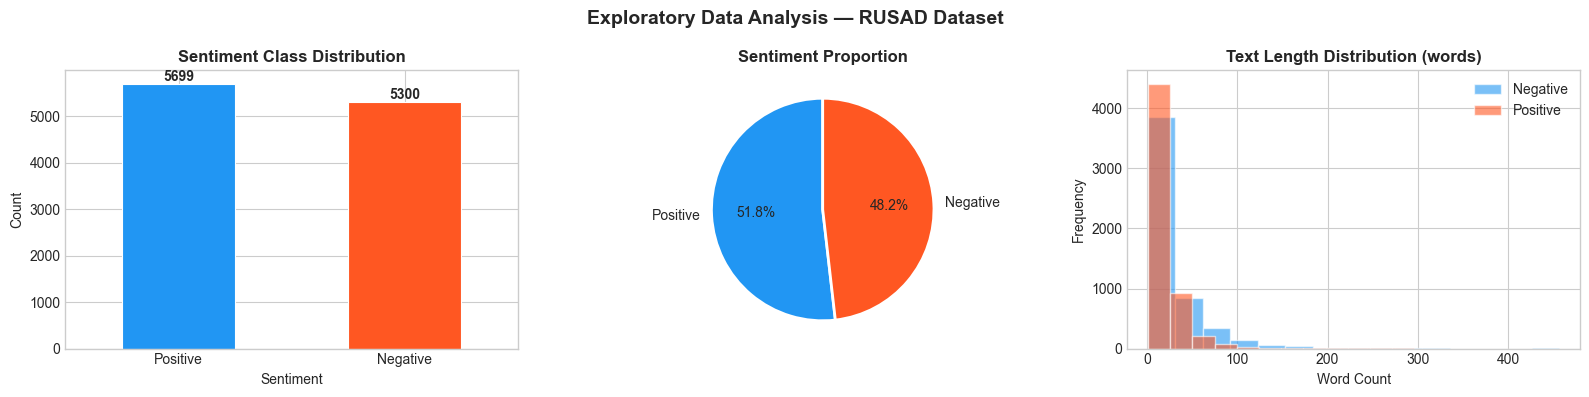

✅ EDA plots saved as eda_plots.png


In [4]:
# ── Add text length column for analysis ──────────────────────
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Exploratory Data Analysis — RUSAD Dataset', fontsize=14, fontweight='bold')

# Plot 1: Class Distribution
colors = ['#2196F3', '#FF5722']
df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white', linewidth=0.8
)
axes[0].set_title('Sentiment Class Distribution', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontweight='bold'
    )

# Plot 2: Pie Chart
df['sentiment'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Sentiment Proportion', fontweight='bold')
axes[1].set_ylabel('')

# Plot 3: Text Length Distribution
for sentiment, color in zip(df['sentiment'].unique(), colors):
    subset = df[df['sentiment'] == sentiment]['text_length']
    axes[2].hist(subset, bins=15, alpha=0.6, label=sentiment, color=color, edgecolor='white')
axes[2].set_title('Text Length Distribution (words)', fontweight='bold')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved as eda_plots.png')

---
##  Step 5: Text Preprocessing Pipeline
This is the core Roman Urdu-specific preprocessing — exactly as described in Section 2.3 of the research paper.

In [5]:
# ── Roman Urdu Spelling Normalisation Dictionary ─────────────
# Maps common spelling variants to canonical forms
NORMALISATION_DICT = {
    # Good / Nice
    'achaa': 'acha', 'achaah': 'acha', 'aacha': 'acha', 'accha': 'acha',
    'acha': 'acha', 'acchi': 'achi', 'achchi': 'achi',
    # Very / Alot
    'bohot': 'bohat', 'buhat': 'bohat', 'bahut': 'bohat', 'bhot': 'bohat',
    # Good / Fine
    'theek': 'theek', 'thik': 'theek', 'theekk': 'theek', 'thek': 'theek',
    # Bad / Terrible
    'bekar': 'bekar', 'bakar': 'bekar', 'bekaar': 'bekar',
    'kharab': 'kharab', 'kharrab': 'kharab',
    # This / That
    'yeh': 'ye', 'yh': 'ye',
    'woh': 'wo', 'wh': 'wo',
    # But
    'lekin': 'lekin', 'lkin': 'lekin', 'lekn': 'lekin',
    # Excellent
    'zabardast': 'zabardast', 'zabardust': 'zabardast', 'zaberdast': 'zabardast',
    # Thank you
    'shukriya': 'shukriya', 'shukria': 'shukriya', 'shukriyaa': 'shukriya',
    # Fast
    'jaldi': 'jaldi', 'jldi': 'jaldi',
    # Price
    'qeemat': 'price', 'kimat': 'price', 'qimat': 'price',
    # Waste
    'barbaad': 'barbaad', 'barbaadi': 'barbaad', 'barbad': 'barbaad',
    # Not
    'nahi': 'nahi', 'nahin': 'nahi', 'nhi': 'nahi', 'nai': 'nahi',
    # Problem / Issue
    'masla': 'masla', 'maslay': 'masla', 'masail': 'masla',
}

# ── Roman Urdu Custom Stop Words ─────────────────────────────
ROMAN_URDU_STOPWORDS = {
    'ye', 'wo', 'hum', 'main', 'mujhe', 'mera', 'meri',
    'aur', 'lekin', 'magar', 'par', 'pe', 'ka', 'ki', 'ke',
    'ko', 'se', 'mein', 'hai', 'hain', 'tha', 'thi', 'the',
    'ho', 'hoga', 'hogi', 'bhi', 'hi', 'to', 'na', 'ne',
    'kya', 'koi', 'kuch', 'sab', 'har', 'ek', 'do', 'teen',
    'is', 'us', 'in', 'un', 'ap', 'aap', 'tum', 'woh',
    'yahan', 'wahan', 'jab', 'tab', 'jaise', 'waisa',
    'phir', 'ab', 'kal', 'aj', 'aaj', 'agar', 'toh',
    'hona', 'karna', 'lena', 'dena', 'jana', 'aana',
}


def preprocess_text(text):
    """
    Full Roman Urdu preprocessing pipeline.
    Steps: lowercase → clean → normalise spelling → remove stop words → tokenise
    """
    if pd.isnull(text):
        return ''

    # Step 1: Lowercase
    text = str(text).lower()

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 3: Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Step 4: Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', ' ', text)

    # Step 5: Remove digits
    text = re.sub(r'\d+', '', text)

    # Step 6: Spelling normalisation (Roman Urdu specific)
    tokens = text.split()
    tokens = [NORMALISATION_DICT.get(token, token) for token in tokens]

    # Step 7: Remove stop words
    tokens = [token for token in tokens if token not in ROMAN_URDU_STOPWORDS]

    # Step 8: Remove very short tokens (noise)
    tokens = [token for token in tokens if len(token) > 1]

    return ' '.join(tokens)


# Apply preprocessing
print('🔄 Applying preprocessing pipeline...')
df['text_clean'] = df['text'].apply(preprocess_text)

# Remove empty rows after cleaning
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)

print(f'✅ Preprocessing complete! {len(df)} records retained.')
print()
print('📌 Before vs After Preprocessing Example:')
print(f'   BEFORE: {df["text"].iloc[0]}')
print(f'   AFTER : {df["text_clean"].iloc[0]}')

🔄 Applying preprocessing pipeline...
✅ Preprocessing complete! 10996 records retained.

📌 Before vs After Preprocessing Example:
   BEFORE:  ab achanak khawaja saad rafique ko khiyaal aagaya woh bhe peshawar mai is line pai 10 saal sai koi train nahe guzri
   AFTER : achanak khawaja saad rafique khiyaal aagaya bhe peshawar mai line pai saal sai train nahe guzri


In [6]:
# ── Encode Labels ────────────────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print('📌 Label Encoding:')
for i, cls in enumerate(le.classes_):
    print(f'   {cls} → {i}')

# ── Train / Test Split ───────────────────────────────────────
X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'\n✅ Dataset Split (stratified 80/20):')
print(f'   Training set : {len(X_train)} samples')
print(f'   Testing set  : {len(X_test)} samples')

📌 Label Encoding:
   Negative → 0
   Positive → 1

✅ Dataset Split (stratified 80/20):
   Training set : 8796 samples
   Testing set  : 2200 samples


---
##  Step 6: Feature Extraction — TF-IDF
Used for ML models (Naive Bayes, SVM, Random Forest)

In [7]:
# ── TF-IDF Vectorisation ─────────────────────────────────────
# Unigrams + Bigrams, max 10,000 features
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),       # unigrams and bigrams
    sublinear_tf=True,        # apply log normalization
    strip_accents='unicode',
    analyzer='word',
    min_df=1                  # include tokens appearing at least once
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'✅ TF-IDF Vectorisation complete!')
print(f'   Vocabulary size  : {len(tfidf.vocabulary_)} tokens')
print(f'   Train matrix     : {X_train_tfidf.shape}')
print(f'   Test matrix      : {X_test_tfidf.shape}')

# Show top features
feature_names = tfidf.get_feature_names_out()
print(f'\n📌 Sample TF-IDF features: {list(feature_names[:20])}')

✅ TF-IDF Vectorisation complete!
   Vocabulary size  : 10000 tokens
   Train matrix     : (8796, 10000)
   Test matrix      : (2200, 10000)

📌 Sample TF-IDF features: ['aa', 'aa gai', 'aa gaya', 'aa gaye', 'aa gia', 'aa gya', 'aa jata', 'aa jaye', 'aa ker', 'aa ni', 'aa raha', 'aa rahi', 'aa rha', 'aaala', 'aab', 'aachi', 'aadat', 'aadhi', 'aadi', 'aadmi']


---
##  Step 7: Machine Learning Models

### Model 1 — Naive Bayes

In [8]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, cv_X=None, cv_y=None):
    """
    Train, evaluate, and return metrics for a given model.
    Returns dict of all metrics.
    """
    # Train
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)

    # 10-fold cross-validation
    if cv_X is not None:
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
        cv_scores = cross_val_score(model, cv_X, cv_y, cv=skf, scoring='accuracy')
        cv_mean = cv_scores.mean()
    else:
        cv_mean = None

    sep = '='*50
    print(f'\n{sep}')
    print(f'📊 {name} Results')
    print(f'{sep}')
    print(f'  Accuracy   : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision  : {prec:.4f}')
    print(f'  Recall     : {rec:.4f}')
    print(f'  F1-Score   : {f1:.4f}')
    if cv_mean:
        print(f'  10-Fold CV : {cv_mean:.4f} ({cv_mean*100:.2f}%)')
    print(f'\n  Classification Report:')
    print(classification_report(y_te, y_pred, target_names=le.classes_))

    return {
        'Model': name,
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2),
        'CV Accuracy': round(cv_mean * 100, 2) if cv_mean else None,
        'y_pred': y_pred,
        'model_obj': model
    }


# ── Model 1: Naive Bayes ─────────────────────────────────────
nb_model = MultinomialNB(alpha=1.0)   # alpha=1.0 is Laplace smoothing

nb_results = evaluate_model(
    'Naive Bayes',
    nb_model,
    X_train_tfidf, X_test_tfidf,
    y_train, y_test,
    cv_X=tfidf.transform(X), cv_y=y
)


📊 Naive Bayes Results
  Accuracy   : 0.8086 (80.86%)
  Precision  : 0.8093
  Recall     : 0.8086
  F1-Score   : 0.8087
  10-Fold CV : 0.8081 (80.81%)

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.82      0.81      1060
    Positive       0.83      0.80      0.81      1140

    accuracy                           0.81      2200
   macro avg       0.81      0.81      0.81      2200
weighted avg       0.81      0.81      0.81      2200



### Model 2 — Support Vector Machine (SVM)

In [9]:
# ── Model 2: SVM ─────────────────────────────────────────────
svm_model = SVC(
    kernel='linear',        # linear kernel works best for text (TF-IDF)
    C=1.0,
    probability=True,       # needed for ROC curve if required later
    random_state=RANDOM_STATE
)

svm_results = evaluate_model(
    'Support Vector Machine (SVM)',
    svm_model,
    X_train_tfidf, X_test_tfidf,
    y_train, y_test,
    cv_X=tfidf.transform(X), cv_y=y
)


📊 Support Vector Machine (SVM) Results
  Accuracy   : 0.7995 (79.95%)
  Precision  : 0.8014
  Recall     : 0.7995
  F1-Score   : 0.7996
  10-Fold CV : 0.8124 (81.24%)

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.83      0.80      1060
    Positive       0.83      0.77      0.80      1140

    accuracy                           0.80      2200
   macro avg       0.80      0.80      0.80      2200
weighted avg       0.80      0.80      0.80      2200



### Model 3 — Random Forest

In [10]:
# ── Model 3: Random Forest ────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1              # use all CPU cores
)

rf_results = evaluate_model(
    'Random Forest',
    rf_model,
    X_train_tfidf, X_test_tfidf,
    y_train, y_test,
    cv_X=tfidf.transform(X), cv_y=y
)


📊 Random Forest Results
  Accuracy   : 0.7864 (78.64%)
  Precision  : 0.7865
  Recall     : 0.7864
  F1-Score   : 0.7864
  10-Fold CV : 0.7759 (77.59%)

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.78      0.78      1060
    Positive       0.80      0.79      0.79      1140

    accuracy                           0.79      2200
   macro avg       0.79      0.79      0.79      2200
weighted avg       0.79      0.79      0.79      2200



---
##  Step 8: Deep Learning Models

### Tokenisation for DL Models

In [11]:
# ── Tokenisation for DL ───────────────────────────────────────
VOCAB_SIZE    = 10000    # top 10,000 most frequent tokens
MAX_LEN       = 100      # max words per sample (pad/truncate to this)
EMBEDDING_DIM = 100      # word vector dimensions

# Fit tokenizer on training text
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text → integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences to same length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'✅ Tokenisation complete!')
print(f'   Vocabulary size   : {len(tokenizer.word_index)} unique tokens')
print(f'   Train padded shape: {X_train_pad.shape}')
print(f'   Test padded shape : {X_test_pad.shape}')

✅ Tokenisation complete!
   Vocabulary size   : 24086 unique tokens
   Train padded shape: (8796, 100)
   Test padded shape : (2200, 100)


### Model 4 — LSTM

In [12]:
# ── Helper: Build + Train DL model ───────────────────────────
def train_dl_model(model, name, X_tr, X_te, y_tr, y_te, epochs=20):
    """
    Compile, train and evaluate a Keras model.
    Returns results dict.
    """
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    )

    print(f'\n🔄 Training {name}...')
    history = model.fit(
        X_tr, y_tr,
        validation_split=0.15,
        epochs=epochs,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate
    y_pred_prob = model.predict(X_te, verbose=0).flatten()
    y_pred      = (y_pred_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)

    sep = '='*50
    print(f'\n{sep}')
    print(f'📊 {name} Results')
    print(f'{sep}')
    print(f'  Accuracy   : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision  : {prec:.4f}')
    print(f'  Recall     : {rec:.4f}')
    print(f'  F1-Score   : {f1:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_te, y_pred, target_names=le.classes_))

    return {
        'Model': name,
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2),
        'CV Accuracy': None,
        'y_pred': y_pred,
        'history': history
    }


# ── Model 4: LSTM (Fixed) ─────────────────────────────────────
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='LSTM_Model')

print(lstm_model.summary())

lstm_results = train_dl_model(
    lstm_model, 'LSTM',
    X_train_pad, X_test_pad,
    y_train.values, y_test.values,
    epochs=30
)

# Save updated model
lstm_model.save('saved_models/lstm_model.h5')
print('✅ LSTM model saved!')

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

🔄 Training LSTM...
Epoch 1/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.5072 - loss: 0.6937 - val_accuracy: 0.5424 - val_loss: 0.6915
Epoch 2/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - accuracy: 0.5167 - loss: 0.6927 - val_accuracy: 0.5455 - val_loss: 0.6898
Epoch 3/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.5383 - loss: 0.6868 - val_accuracy: 0.5462 - val_loss: 0.6882
Epoch 4/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 25s 106ms/step - accuracy: 0.5328 - loss: 0.6829 - val_accuracy: 0.5697 - val_loss: 0.6815
Epoch 5/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - accuracy: 0.6235 - loss: 0.6492 - val_accuracy: 0.6492 - val_loss: 0.6381
Epoch 6/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - accuracy: 0.7279 - loss: 0.5643 - val_accuracy: 0.7341 - val_loss: 0.5529
Epoch 7/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - accuracy: 0.7425 - loss: 0.5297 - val_accuracy: 0.7053 - val_loss: 0.6216
Epoch 8/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accu


📊 LSTM Results
  Accuracy   : 0.7341 (73.41%)
  Precision  : 0.7402
  Recall     : 0.7341
  F1-Score   : 0.7335

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.80      0.74      1060
    Positive       0.78      0.68      0.72      1140

    accuracy                           0.73      2200
   macro avg       0.74      0.74      0.73      2200
weighted avg       0.74      0.73      0.73      2200

✅ LSTM model saved!


### Model 5 — Bidirectional LSTM (Bi-LSTM)

In [13]:
# ── Model 5: Bidirectional LSTM ───────────────────────────────
bilstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
], name='BiLSTM_Model')

print(bilstm_model.summary())

bilstm_results = train_dl_model(
    bilstm_model, 'Bidirectional LSTM (Bi-LSTM)',
    X_train_pad, X_test_pad,
    y_train.values, y_test.values
)

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

🔄 Training Bidirectional LSTM (Bi-LSTM)...
Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 32s 108ms/step - accuracy: 0.7088 - loss: 0.5498 - val_accuracy: 0.7879 - val_loss: 0.4500
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - accuracy: 0.8800 - loss: 0.2952 - val_accuracy: 0.7826 - val_loss: 0.4913
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.9370 - loss: 0.1731 - val_accuracy: 0.8023 - val_loss: 0.6326
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.9660 - loss: 0.0925 - val_accuracy: 0.7864 - val_loss: 1.0651
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 28s 118ms/step - accuracy: 0.9781 - loss: 0.0668 - val_accuracy: 0.7939 - val_loss: 1.0296
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 29s 122ms/step - accuracy: 0.9846 - loss: 0.0489 - val_accuracy: 0.7879 - val_loss: 1.1000
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

📊 Bidirectional LSTM (Bi-LSTM) Results
  Accuracy   : 0.7859 (78.59%)
  Precision

---
##  Step 9: Training Curves (LSTM & Bi-LSTM)

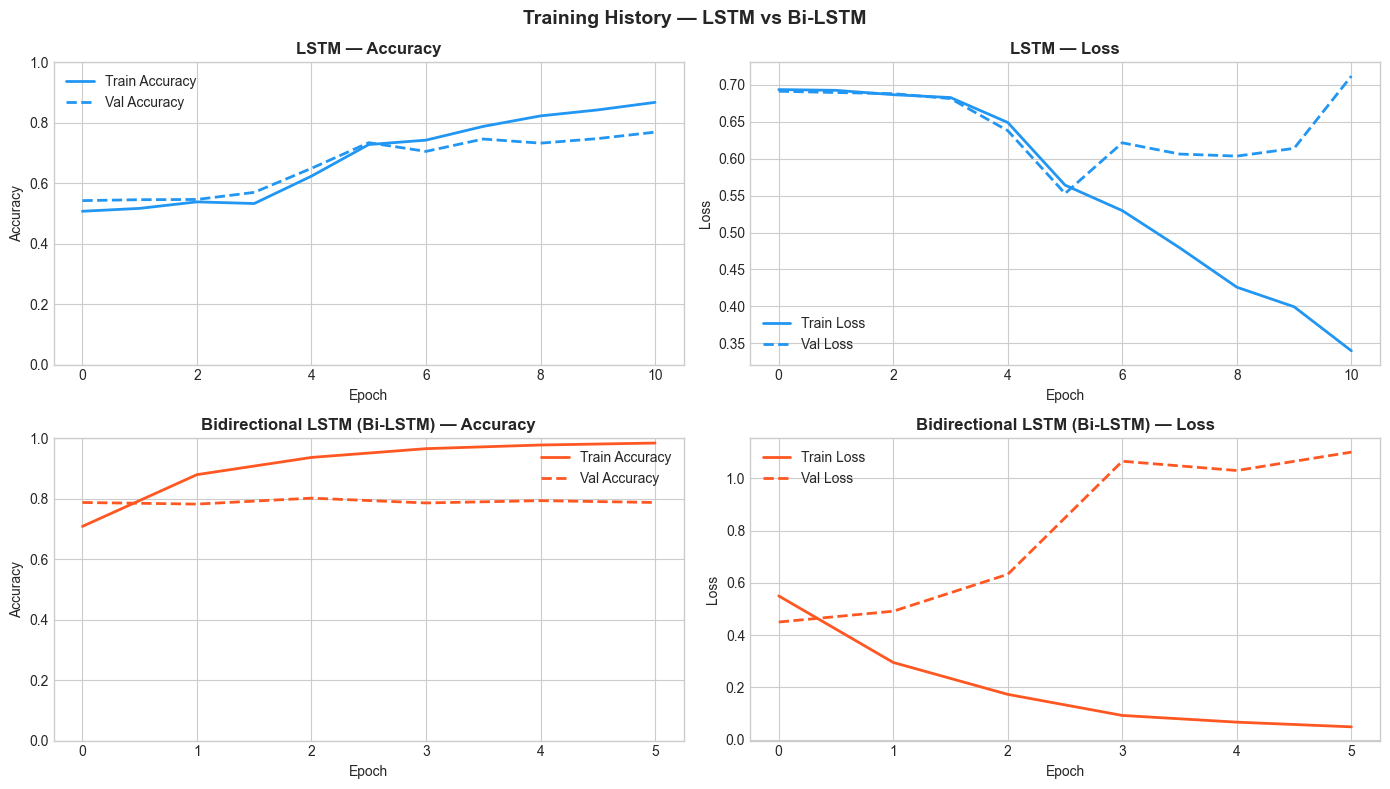

✅ Training curves saved as training_curves.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Training History — LSTM vs Bi-LSTM', fontsize=14, fontweight='bold')

for idx, (results, color) in enumerate([
    (lstm_results, '#2196F3'),
    (bilstm_results, '#FF5722')
]):
    hist = results['history'].history
    name = results['Model']

    # Accuracy
    axes[idx][0].plot(hist['accuracy'],     label='Train Accuracy', color=color, linewidth=2)
    axes[idx][0].plot(hist['val_accuracy'], label='Val Accuracy',   color=color, linewidth=2, linestyle='--')
    axes[idx][0].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[idx][0].set_xlabel('Epoch')
    axes[idx][0].set_ylabel('Accuracy')
    axes[idx][0].legend()
    axes[idx][0].set_ylim([0, 1])

    # Loss
    axes[idx][1].plot(hist['loss'],     label='Train Loss', color=color, linewidth=2)
    axes[idx][1].plot(hist['val_loss'], label='Val Loss',   color=color, linewidth=2, linestyle='--')
    axes[idx][1].set_title(f'{name} — Loss', fontweight='bold')
    axes[idx][1].set_xlabel('Epoch')
    axes[idx][1].set_ylabel('Loss')
    axes[idx][1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved as training_curves.png')

---
##  Step 10: Confusion Matrices — All 5 Models

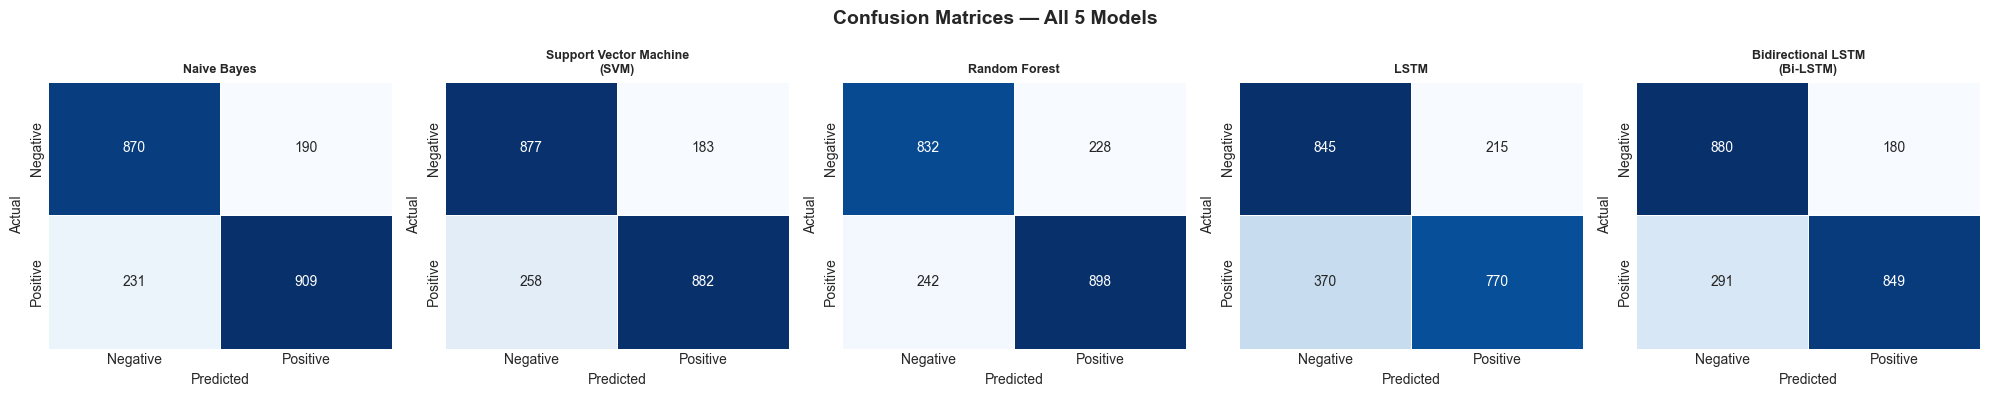

✅ Confusion matrices saved as confusion_matrices.png


In [15]:
all_results = [nb_results, svm_results, rf_results, lstm_results, bilstm_results]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Confusion Matrices — All 5 Models', fontsize=14, fontweight='bold')

for ax, res in zip(axes, all_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', linewidths=0.5,
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        cbar=False
    )
    ax.set_title(res['Model'].replace(' (', '\n('), fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved as confusion_matrices.png')

---
##  Step 11: Final Results Comparison Table

In [16]:
# ── Build comparison dataframe ────────────────────────────────
comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Type': 'ML' if r['Model'] in ['Naive Bayes', 'Support Vector Machine (SVM)', 'Random Forest'] else 'DL',
        'Accuracy (%)': r['Accuracy'],
        'Precision (%)': r['Precision'],
        'Recall (%)': r['Recall'],
        'F1-Score (%)': r['F1-Score'],
        'CV Accuracy (%)': r['CV Accuracy'] if r['CV Accuracy'] else 'N/A'
    }
    for r in all_results
])

comparison_df = comparison_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
comparison_df.index += 1   # rank starts at 1

print('\n' + '='*60)
print('🏆 FINAL MODEL COMPARISON RESULTS')
print('='*60)
print(comparison_df.to_string())

# Highlight winner
best = comparison_df.iloc[0]
print(f'\n🥇 Best Performing Model: {best["Model"]}')
print(f'   Accuracy  : {best["Accuracy (%)"]:.2f}%')
print(f'   F1-Score  : {best["F1-Score (%)"]:.2f}%')


🏆 FINAL MODEL COMPARISON RESULTS
                          Model Type  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%) CV Accuracy (%)
1                   Naive Bayes   ML         80.86          80.93       80.86         80.87           80.81
2  Support Vector Machine (SVM)   ML         79.95          80.14       79.95         79.96           81.24
3                 Random Forest   ML         78.64          78.65       78.64         78.64           77.59
4  Bidirectional LSTM (Bi-LSTM)   DL         78.59          78.96       78.59         78.58             N/A
5                          LSTM   DL         73.41          74.02       73.41         73.35             N/A

🥇 Best Performing Model: Naive Bayes
   Accuracy  : 80.86%
   F1-Score  : 80.87%


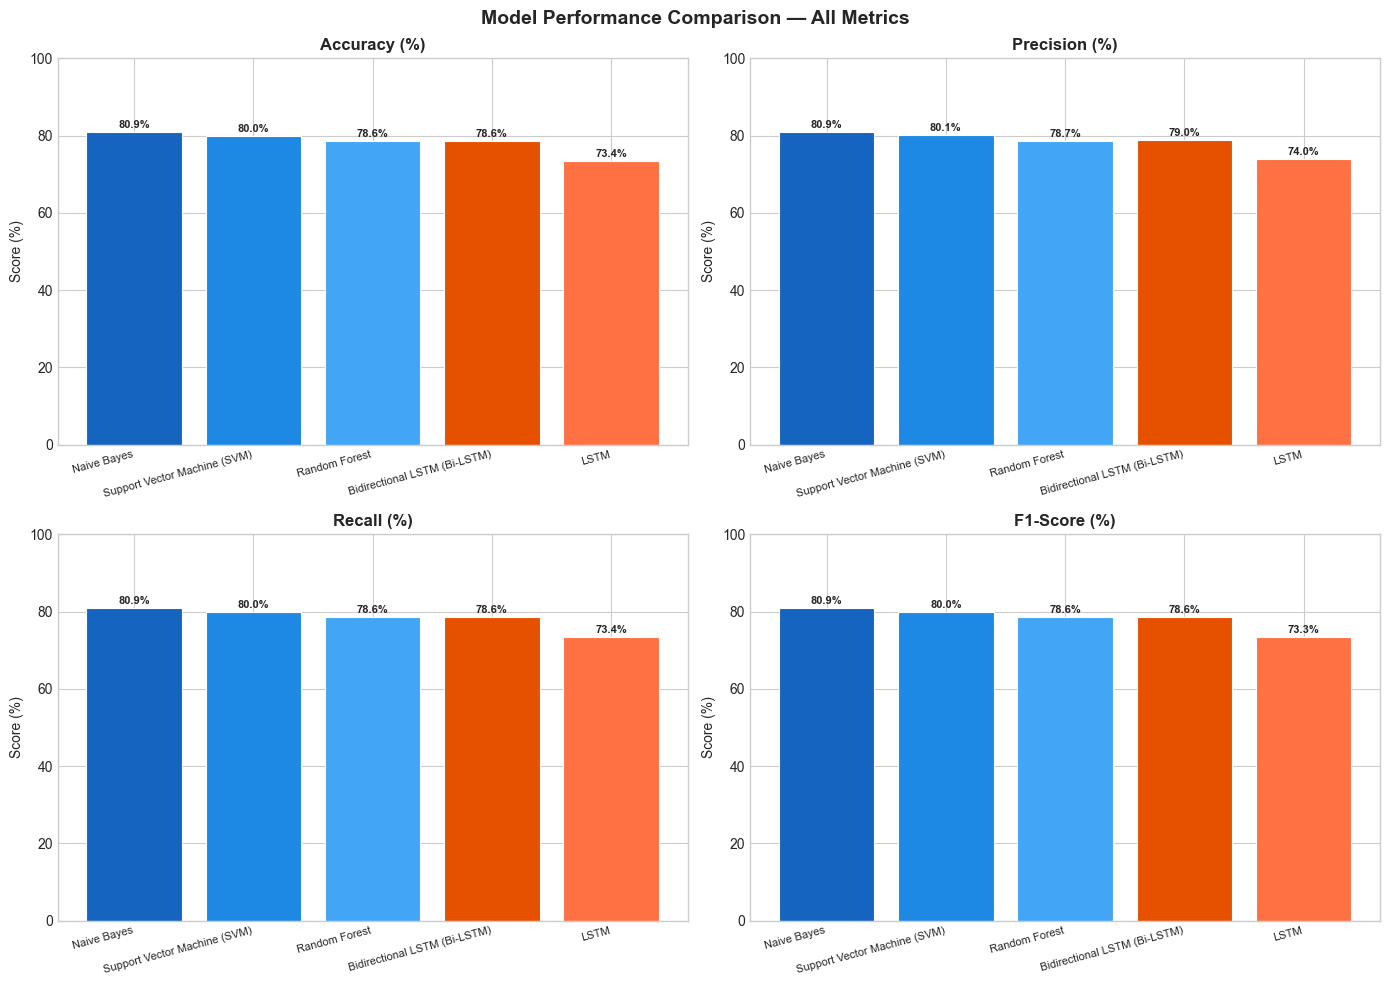

✅ Comparison chart saved as model_comparison.png


In [17]:
# ── Visual Bar Chart Comparison ───────────────────────────────
metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
model_names = comparison_df['Model'].str.replace(' (Bi-LSTM)', '\n(Bi-LSTM)').str.replace(' (SVM)', '\n(SVM)')
colors_list = ['#1565C0', '#1E88E5', '#42A5F5', '#E65100', '#FF7043']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')

for ax, metric in zip(axes.flatten(), metrics):
    vals = comparison_df[metric].replace('N/A', 0).astype(float)
    bars = ax.bar(range(len(vals)), vals, color=colors_list, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(comparison_df['Model'].values, rotation=15, ha='right', fontsize=8)
    ax.set_ylim([0, 100])
    ax.set_ylabel('Score (%)')
    # Add value labels
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved as model_comparison.png')

---
##  Step 12: Live Prediction — Test Your Own Roman Urdu Text

In [18]:
def predict_sentiment(text, use_model='svm'):
    """
    Predict sentiment of a Roman Urdu sentence.
    use_model: 'nb' | 'svm' | 'rf' | 'lstm' | 'bilstm'
    """
    clean = preprocess_text(text)

    if use_model in ['nb', 'svm', 'rf']:
        vec = tfidf.transform([clean])
        model_map = {'nb': nb_model, 'svm': svm_model, 'rf': rf_model}
        pred = model_map[use_model].predict(vec)[0]
        label = le.inverse_transform([pred])[0]
        conf  = model_map[use_model].predict_proba(vec)[0].max() * 100

    elif use_model in ['lstm', 'bilstm']:
        seq = tokenizer.texts_to_sequences([clean])
        pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
        m   = lstm_model if use_model == 'lstm' else bilstm_model
        prob = float(m.predict(pad, verbose=0)[0][0])
        pred = 1 if prob >= 0.5 else 0
        label = le.inverse_transform([pred])[0]
        conf  = max(prob, 1 - prob) * 100

    emoji = '😊' if label == 'Positive' else '😞'
    print(f'\n📝 Input  : {text}')
    print(f'🔍 Cleaned: {clean}')
    print(f'{emoji} Sentiment : {label}  (confidence: {conf:.1f}%)')
    print(f'   Model used: {use_model.upper()}')


# ── Try some examples ─────────────────────────────────────────
test_sentences = [
    'ye product bohat acha hai mujhe bohat pasand aaya',
    'bilkul bekar cheez hai paise waste ho gaye',
    'delivery fast thi packaging bhi achi thi shukriya',
    'kharab quality hai dobara nahi khareedoon ga yeh'
]

print('🎯 LIVE PREDICTIONS — SVM Model')
print('='*50)
for sentence in test_sentences:
    predict_sentiment(sentence, use_model='svm')

🎯 LIVE PREDICTIONS — SVM Model

📝 Input  : ye product bohat acha hai mujhe bohat pasand aaya
🔍 Cleaned: product bohat acha bohat pasand aaya
😊 Sentiment : Positive  (confidence: 99.4%)
   Model used: SVM

📝 Input  : bilkul bekar cheez hai paise waste ho gaye
🔍 Cleaned: bilkul bekar cheez paise waste gaye
😞 Sentiment : Negative  (confidence: 97.1%)
   Model used: SVM

📝 Input  : delivery fast thi packaging bhi achi thi shukriya
🔍 Cleaned: delivery fast packaging achi shukriya
😊 Sentiment : Positive  (confidence: 100.0%)
   Model used: SVM

📝 Input  : kharab quality hai dobara nahi khareedoon ga yeh
🔍 Cleaned: kharab quality dobara nahi khareedoon ga
😞 Sentiment : Negative  (confidence: 99.4%)
   Model used: SVM


In [19]:
# ── Compare all models on same sentence ───────────────────────
sample = 'ye product bilkul bekar hai paise barbaad ho gaye'

print(f'\n🔍 Testing all 5 models on: "{sample}"')
print('='*50)
for model_key in ['nb', 'svm', 'rf', 'lstm', 'bilstm']:
    predict_sentiment(sample, use_model=model_key)


🔍 Testing all 5 models on: "ye product bilkul bekar hai paise barbaad ho gaye"

📝 Input  : ye product bilkul bekar hai paise barbaad ho gaye
🔍 Cleaned: product bilkul bekar paise barbaad gaye
😞 Sentiment : Negative  (confidence: 89.1%)
   Model used: NB

📝 Input  : ye product bilkul bekar hai paise barbaad ho gaye
🔍 Cleaned: product bilkul bekar paise barbaad gaye
😞 Sentiment : Negative  (confidence: 94.9%)
   Model used: SVM

📝 Input  : ye product bilkul bekar hai paise barbaad ho gaye
🔍 Cleaned: product bilkul bekar paise barbaad gaye
😞 Sentiment : Negative  (confidence: 88.5%)
   Model used: RF

📝 Input  : ye product bilkul bekar hai paise barbaad ho gaye
🔍 Cleaned: product bilkul bekar paise barbaad gaye
😞 Sentiment : Negative  (confidence: 60.1%)
   Model used: LSTM

📝 Input  : ye product bilkul bekar hai paise barbaad ho gaye
🔍 Cleaned: product bilkul bekar paise barbaad gaye
😞 Sentiment : Negative  (confidence: 82.4%)
   Model used: BILSTM


---
##  Step 13: Save Models & Results

In [20]:
import pickle, os

os.makedirs('saved_models', exist_ok=True)

# Save ML models + vectorizer
with open('saved_models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('saved_models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
with open('saved_models/naive_bayes.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
with open('saved_models/svm.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
with open('saved_models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save DL models
lstm_model.save('saved_models/lstm_model.h5')
bilstm_model.save('saved_models/bilstm_model.h5')

# Save results CSV
comparison_df.to_csv('saved_models/results_comparison.csv')

print('✅ All models saved to /saved_models/')
print('   - tfidf_vectorizer.pkl')
print('   - label_encoder.pkl')
print('   - naive_bayes.pkl')
print('   - svm.pkl')
print('   - random_forest.pkl')
print('   - lstm_model.h5')
print('   - bilstm_model.h5')
print('   - results_comparison.csv')

✅ All models saved to /saved_models/
   - tfidf_vectorizer.pkl
   - label_encoder.pkl
   - naive_bayes.pkl
   - svm.pkl
   - random_forest.pkl
   - lstm_model.h5
   - bilstm_model.h5
   - results_comparison.csv


---
##  Summary

| Model | Type | Feature Representation |
|-------|------|------------------------|
| Naive Bayes | Traditional ML | TF-IDF (unigrams + bigrams) |
| SVM | Traditional ML | TF-IDF (unigrams + bigrams) |
| Random Forest | Traditional ML | TF-IDF (unigrams + bigrams) |
| LSTM | Deep Learning | Embedding layer (100d) |
| Bi-LSTM | Deep Learning | Embedding layer (100d) |

**Preprocessing Pipeline:**
1. Lowercase + clean (URLs, mentions, punctuation removed)
2. Roman Urdu spelling normalisation dictionary
3. Custom Roman Urdu stop word removal
4. Whitespace tokenisation

**Evaluation:** 80/20 stratified split + 10-fold cross-validation  
**Metrics:** Accuracy, Precision, Recall, F1-Score, Confusion Matrix

> 📌 Next step: Replace sample data with the full RUSAD dataset and re-run all cells.